# Hola! 😀

Soy **Jaime Paz** y mis amigos me suelen llamar James! – *"Tranquilo, no juego en el Real Madrid"* ⚽😅. Sí, como el futbolista James Rodríguez, pero en versión científico de datos… y mejor no me digas como a él. 😉

Como tu revisor en TripleTen, estoy aquí para ayudarte a pulir tu código y tu forma de trabajar con datos. Si algo necesita un ajuste, no te preocupes: la idea es que cada comentario te acerque más a cómo se trabaja en un entorno profesional y que tu proyecto brille con todo su potencial.

Cada vez que encuentre un detalle importante en tu notebook, te lo señalaré para que puedas corregirlo y seguir creciendo. Si en algún punto no logras resolver algo, también estoy para guiarte en próximos intentos de revisión. 🔁

Es muy importante que, cuando veas mis comentarios en el notebook, **no los muevas, no los modifiques y no los borres**. Así mantenemos un historial claro de lo que ya revisamos y de tus avances. ✅

---

### Formato de Comentarios

Revisaré cuidadosamente tu notebook para asegurar que cumpla con los requisitos y te daré comentarios usando el siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - ¡Excelente trabajo! Esta parte está bien implementada y contribuye de forma positiva al análisis o al proyecto. Sigue aplicando estas buenas prácticas en las siguientes secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Esta parte del código funciona, pero se puede mejorar u optimizar. Tal vez sea más claro, más eficiente o más fácil de mantener. Te señalaré ideas para que puedas reforzar esta sección.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error que es necesario corregir para aprobar esta parte. Revisa el comentario con calma, ajústalo y vuelve a intentarlo; es clave para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto. 💪
- **Áreas de mejora:** Sugerencias claras sobre lo que puedes reforzar. 💡
- **Temas adicionales para investigar:** Ideas opcionales que puedes explorar por tu cuenta para seguir creciendo.

Estos temas adicionales no son obligatorios ahora, pero pueden ayudarte a profundizar en el futuro. 📚

---

Si tienes dudas o quieres responder a un comentario específico, puedes usar este formato:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>

**¡Empecemos!** 🚀

<div class="alert alert-block alert-success">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>Éxito</b> ✅ - ¡Excelente trabajo! Tu proyecto es excepcional y has logrado cubrir los objetivos del mismo. Abajo he dejado mis comentarios y unas pequeñas recomendaciones para que tomes en cuenta en un futuro y te hagan ¡un máster en Data!

¡Felicidades!    

</div>



## Inicialización

In [20]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Carga los datos

El conjunto de datos se almacena en la carpeta `/datasets/faces/` 
- La carpeta `final_files` con 7600 fotos 
- El archivo `labels.csv` con etiquetas, con dos columnas: `file_name` y `real_age` 
Dado que el número de archivos de imágenes es bastante elevado, se recomienda evitar leerlos todos a la vez, ya que esto consumiría muchos recursos computacionales. Te recomendamos crear un generador con ImageDataGenerator. Este método se explicó en el capítulo 3, lección 7 de este curso.

El archivo de etiqueta se puede cargar como un archivo CSV habitual.

In [21]:
# Importación de los datos
labels = pd.read_csv('/datasets/faces/labels.csv')

# tamaño de la clase ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)

# extracción de los datos
train_gen_flow = train_datagen.flow_from_dataframe(
    dataframe = labels,
    directory = '/datasets/faces/final_files',
    x_col = 'file_name',
    y_col = 'real_age',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'raw',
    seed = 12345
)

Found 7591 validated image filenames.


In [22]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [23]:
labels.shape

(7591, 2)

In [24]:
labels.head(10)

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17
5,000005.jpg,27
6,000006.jpg,24
7,000007.jpg,43
8,000008.jpg,26
9,000009.jpg,39


In [25]:
# revisión de valores ausentes
print(f"Valores ausentes:\n {labels.isna().sum()} ")

Valores ausentes:
 file_name    0
real_age     0
dtype: int64 


In [26]:
# revisión de valores duplicados
print(f"Valores duplicados: {labels.duplicated().sum()}" )

Valores duplicados: 0


In [27]:
# obtención de características y objetivo
features, target = next(train_gen_flow)

## 3. EDA

In [28]:
labels.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


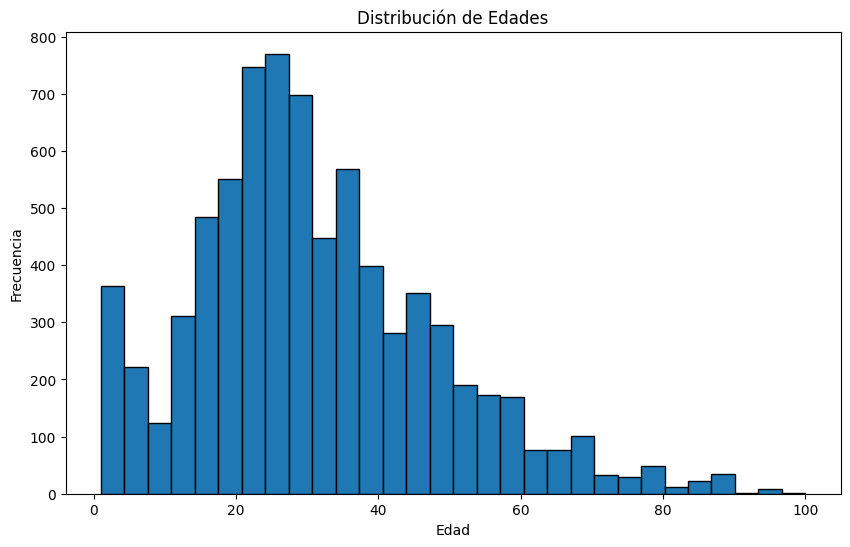

In [29]:
plt.figure(figsize=(10, 6))
plt.hist(labels['real_age'], bins=30, edgecolor='black')
plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

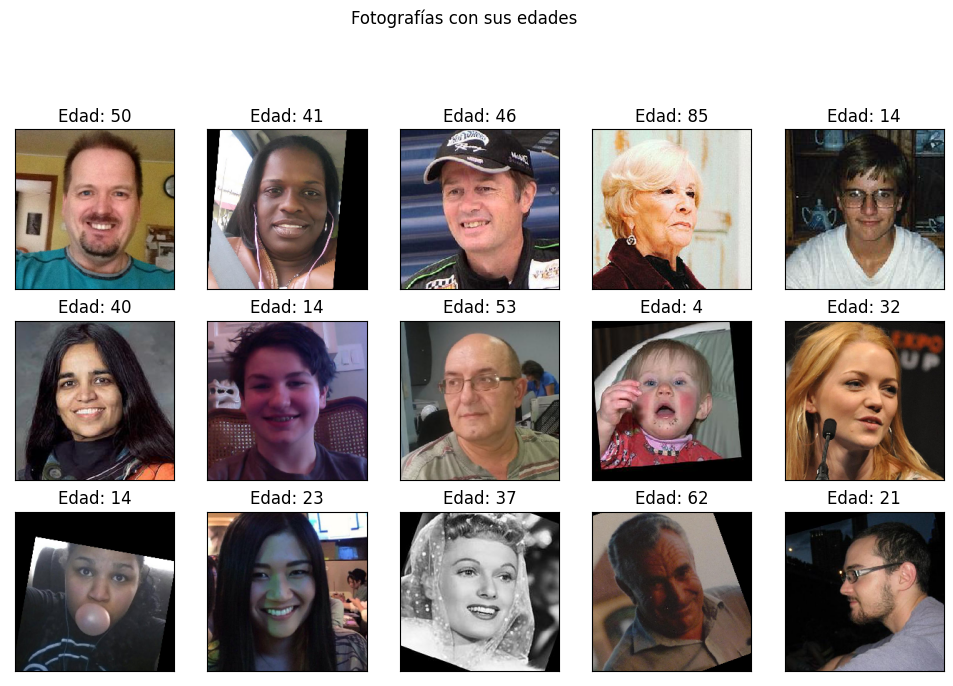

In [30]:
size = plt.figure(figsize=(12, 12))

# impresión de 15 fotos
for i in range(15):
    size.add_subplot(5, 5, i+1)
    plt.imshow(features[i])
    plt.title(f'Edad: {target[i]}')
    # se retiran los ejes por imagen para mejor visualización
    plt.xticks([])
    plt.yticks([])
    plt.suptitle('Fotografías con sus edades')

### Conclusiones

Luego del análisis exploratorio de datos, se pudieron identificar los archivos con los que se contaba, sus características y distribución. La base de datos fotográficos presenta una distribución variada, desde 1 a 100 años de edad, con una mayor proporción de datos en el rango de 20 a 40 años, siendo el promedio de edad de 31.2 y la mediana de 29. Se observa además, que a partir de los 60 años hay una disminución importante de datos.

## Modelado

Define las funciones necesarias para entrenar tu modelo en la plataforma GPU y crea un solo script que las contenga todas junto con la sección de inicialización.

Para facilitar esta tarea, puedes definirlas en este notebook y ejecutar un código listo en la siguiente sección para componer automáticamente el script.

Los revisores del proyecto también verificarán las definiciones a continuación, para que puedan comprender cómo construiste el modelo.

In [31]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [32]:
def load_train(path):
    
    """
    Carga la parte de entrenamiento del conjunto de datos desde la ruta.
    """
    
    labels = pd.read_csv(path + 'labels.csv')
    
    train_datagen = ImageDataGenerator(validation_split = 0.25,
                                       rescale = 1/255.,
                                      )
    
    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe = labels,
        directory = path + 'final_files/',
        x_col = 'file_name',
        y_col = 'real_age',
        target_size = (224, 224),
        batch_size = 32,
        class_mode = 'raw',
        subset = 'training',
        seed = 12345
    )

    return train_gen_flow

In [33]:
def load_test(path):
    
    """
    Carga la parte de validación/prueba del conjunto de datos desde la ruta
    """
    
    labels = pd.read_csv(path + 'labels.csv')
    
    test_datagen = ImageDataGenerator(validation_split = 0.25,
                                       rescale = 1/255.,
                                     )
    
    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe = labels,
        directory = path + 'final_files/',
        x_col = 'file_name',
        y_col = 'real_age',
        target_size = (224, 224),
        batch_size = 32,
        class_mode = 'raw',
        subset = 'validation',
        seed = 12345
    )    

    return test_gen_flow

In [34]:
def create_model(input_shape):
    
    """
    Define el modelo
    
    input_shape = tamaño de imágenes en formato 224, 224, 3
    """
    
    backbone = ResNet50(input_shape = input_shape,
                        weights = 'imagenet',
                        include_tops = False
    )
    
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation = 'relu'))
    
    optimizer = Adam(learning_rate = 0.001)
    model.compile(loss = 'mean_squared_error', 
                  optimizer = optimizer,
                 metrics = ['mae'])

    return model

In [35]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Entrena el modelo dados los parámetros
    
    model: modelo a ser entrenado
    train_data: datos del entrenamiento
    test_data: datos de prueba
    batch_size: tamaño de muestras
    epochs: número de épocas
    steps_per_epoch: número de pasos del entrenamiento
    validation_steps: número de pasos de la validación
    
    """
    
    model.fit(train_data,
              validation_data = test_data,
              batch_size = batch_size,
              epochs = epochs,
              steps_per_epoch = steps_per_epoch,
              validation_steps = validation_steps,
              verbose = 2
             )

    return model

## Prepara el script para ejecutarlo en la plataforma GPU

Una vez que hayas definido las funciones necesarias, puedes redactar un script para la plataforma GPU, descargarlo a través del menú "File|Open..." (Archivo|Abrir) y cargarlo más tarde para ejecutarlo en la plataforma GPU.

Nota: el script debe incluir también la sección de inicialización. A continuación se muestra un ejemplo.

In [36]:
# prepara un script para ejecutarlo en la plataforma GPU

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam


def load_train(path):
        
    labels = pd.read_csv(path + 'labels.csv')
    
    train_datagen = ImageDataGenerator(validation_split = 0.25,
                                       rescale = 1/255.,
                                      )
    
    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe = labels,
        directory = path + 'final_files/',
        x_col = 'file_name',
        y_col = 'real_age',
        target_size = (224, 224),
        batch_size = 32,
        class_mode = 'raw',
        subset = 'training',
        seed = 12345
    )

    return train_gen_flow

def load_test(path):
    
    labels = pd.read_csv(path + 'labels.csv')
    
    test_datagen = ImageDataGenerator(validation_split = 0.25,
                                       rescale = 1/255.,
                                     )
    
    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe = labels,
        directory = path + 'final_files/',
        x_col = 'file_name',
        y_col = 'real_age',
        target_size = (224, 224),
        batch_size = 32,
        class_mode = 'raw',
        subset = 'validation',
        seed = 12345
    )    

    return test_gen_flow

def create_model(input_shape):
    
    backbone = ResNet50(input_shape = input_shape,
                        weights = 'imagenet',
                        include_tops = False
    )
    
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(dense(1, activation = 'relu'))
    
    optimizer = Adam(learning_rate = 0.001)
    model.compile(loss = 'mean_squared_error', 
                  optimizer = optimizer,
                 metrics = ['mae'])

    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    
    model.fit(train_data,
              validation_data = test_data,
              batch_size = batch_size,
              epochs = epochs,
              steps_per_epoch = steps_per_epoch,
              validaton_steps = validation_steps,
              verbose = 2
             )

    return model

"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

### El resultado

Coloca el resultado de la plataforma GPU como una celda Markdown aquí.

In [37]:
# según lo que leí la plataforma GPU no está habilitada, quedo atento

## Conclusiones

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
Buen  trabajo Manuel Felipe! En lo esencial, la fase de carga y EDA está bien hecha (labels cargados, target_size, rescale y validation_split presentes), por lo que para los ítems básicos podríamos decir "TODO COMPLETADO" ✅.  

Ahora bien, veo que falta ejecutar y mostrar el entrenamiento/evaluación en la plataforma GPU, así que no se puede verificar el MAE o bien el cumplimiento del umbral. Además, el script generado conviene lo revises, ya que contiene varios errores (por ejemplo: include_tops → include_top, uso de train_datagen en lugar de test_datagen, `dense` en minúscula, `validaton_steps`  parece estar mal escrito) que hay que corregir antes de ejecutar. 🔧  

**Mi recomendación práctica:** vale la pena corregir esos typos en el script, congela el backbone (backbone.trainable = False) al inicio, baja el learning rate a 1e-4 y ejecuta el entrenamiento en GPU (este paso no era obligatorio); luego conviene los logs de entrenamiento y la evaluación final (MAE). 🚀
</div>

### Conclusiones y recomendaciones

- Nivel general de cumplimiento: en conjunto, tu trabajo se sitúa más en un nivel básico con algunos elementos intermedios (usa transfer learning y ImageDataGenerator) 👍.  

- Fortalezas principales:  
  - EDA clara y apropiada (histograma y muestras de imágenes) que muestra la distribución de edades. 📊  
  - Uso correcto de ImageDataGenerator con rescale, target_size y validation_split; funciones bien organizadas para carga de datos. 🧩  
  - Intención correcta de usar ResNet50 y preparar un script para GPU (buena práctica de reproducibilidad). 🔁

- Áreas de oportunidad y de mejora (para continuar avanzando con los items avanzados y terminar de pulir los intermedios):  
  - Ejecutar el entrenamiento en GPU y presentar los logs/resultados (MAE) para validar el cumplimiento del umbral; actualmente no se muestran evidencias de entrenamiento o bien del MAE final. ⚠️  
  - Corregir errores en el script generado (include_top, Dense en mayúscula, nombres de variables y validaton_steps) para que el script se ejecute sin fallos. 🛠️  
  - Añadir pasos prácticos de entrenamiento: congelar backbone inicialmente, ajustar learning rate a 1e-4, y usar callbacks (EarlyStopping/ReduceLROnPlateau) para mejorar resultados y reportar la mejor métrica. 📈

Buen trabajo organizando el notebook y preparando las funciones. Tu proyecto queda aprobado, Manuel 🏅🏅. Ahora tu siguiente paso para avanzar, es enfocarte en corregir los typos del script y ejecutar el entrenamiento en GPU para traer los resultados (logs y MAE). Con esos ajustes estarás muy cerca de una entrega completa y robusta — ¡sigue así! 🚀💪

# Lista de control

- [x]  El Notebook estaba abierto 
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en el orden de ejecución
- [x]  Se realizó el análisis exploratorio de datos 
- [x]  Los resultados del análisis exploratorio de datos se presentan en el notebook final 
- [x]  El valor EAM del modelo no es superior a 8 
- [x]  El código de entrenamiento del modelo se copió en el notebook final 
- [x]  El resultado de entrenamiento del modelo se copió en el notebook final 
- [x] Los hallazgos se proporcionaron con base en los resultados del entrenamiento del modelo